# Diamond Data Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline



In [4]:
df = pd.read_csv('diamonds_spring_2024.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,x0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.shape

(53940, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  object 
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 4.5+ MB


In [7]:
df.describe()

,Unnamed: 0,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [8]:
to_rename = 'Unnamed: 0'
if to_rename in df.columns:
    df.rename(columns={to_rename: 'id'}, inplace=True)
    df.set_index('id', inplace=True)


In [9]:
for column in df.columns:
    print(f'Column {column} has {len(df[column].unique())} discrete values')

Column carat has 274 discrete values
Column cut has 5 discrete values
Column color has 7 discrete values
Column clarity has 8 discrete values
Column depth has 184 discrete values
Column table has 127 discrete values
Column price has 11602 discrete values
Column x has 554 discrete values
Column y has 552 discrete values
Column z has 375 discrete values


In [10]:
categorical_columns = ['cut', 'color', 'clarity']
for column in categorical_columns:
    df[column] = pd.Categorical(df[column])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  object  
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(5), int64(1), object(1)
memory usage: 3.4+ MB


In [11]:
invalid_table_data = ~df['carat'].astype(str).str.replace('.', '').astype(str).str.isnumeric()
df.loc[invalid_table_data, 'carat'] = 0
df['carat'] = df['carat'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


In [12]:
columns = df.select_dtypes(include='number').columns
for column in columns:
    print(f'number of negative {column} values: {(df[column] < 0).sum()}')


number of negative carat values: 0
number of negative depth values: 0
number of negative table values: 0
number of negative price values: 0
number of negative x values: 0
number of negative y values: 0
number of negative z values: 0


In [13]:
df['depth'] = df['depth'].abs()
print(f'number of negative table values: {(df["depth"] < 0).sum()}')
df.head()

number of negative table values: 0


,carat,cut,color,clarity,depth,table,price,x,y,z
id,,,,,,,,,,
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.00,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Visualisierung

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

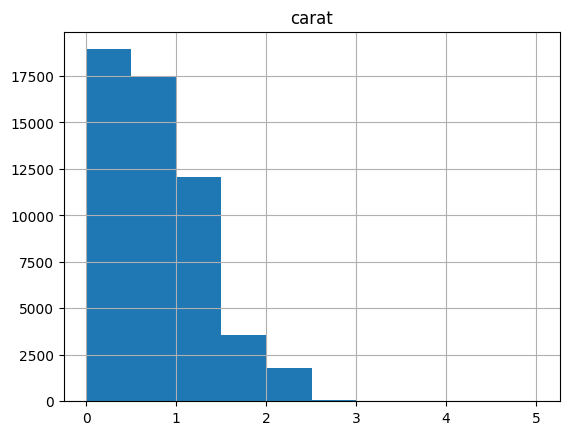

In [14]:
df.hist('carat')

<Axes: >

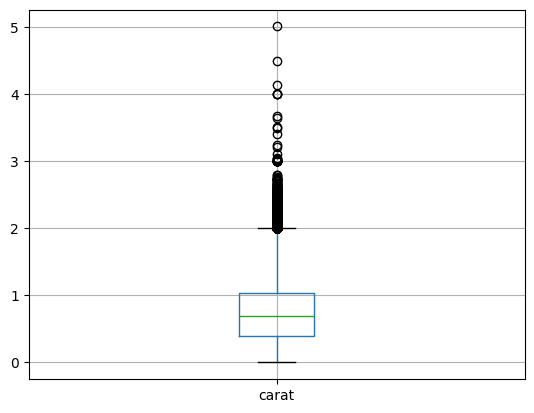

In [15]:
df.boxplot('carat')

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

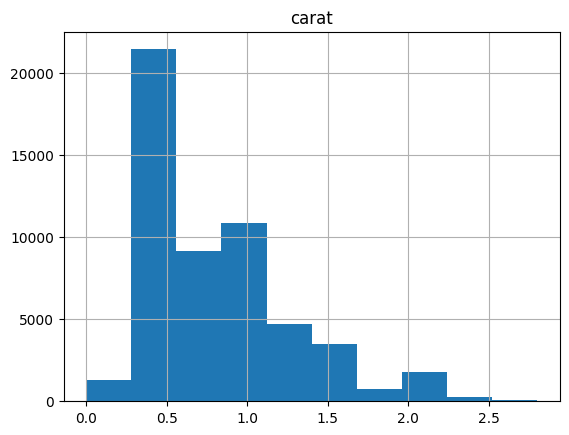

In [16]:
df[df['carat'] < 3].hist('carat')

<Axes: title={'center': 'price'}, xlabel='clarity'>

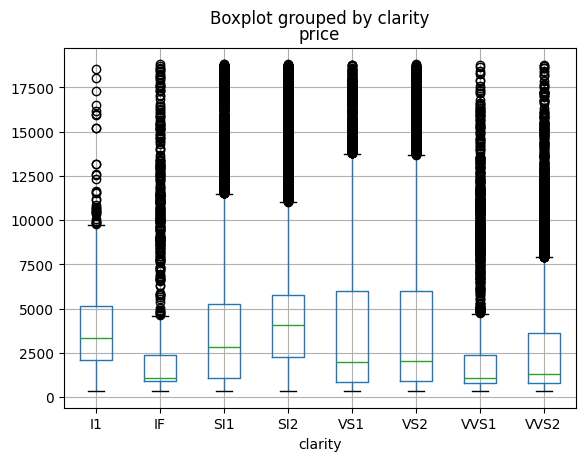

In [17]:
df.boxplot(column='price', by='clarity')

<Axes: ylabel='Density'>

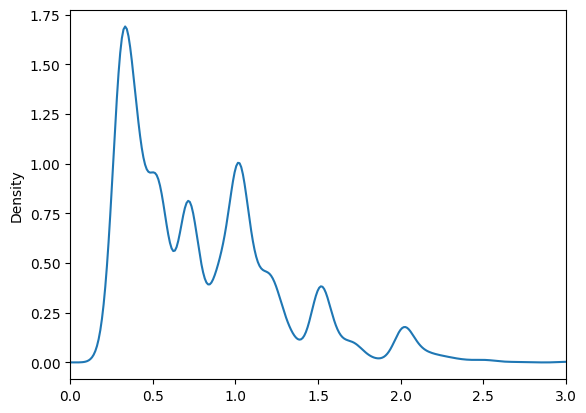

In [18]:
df['carat'].plot(kind='density', xlim=(0,3))

## Korrelationen

<Axes: >

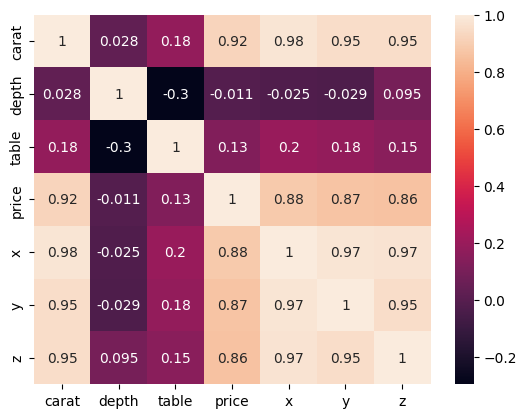

In [19]:
sns.heatmap(df[df.select_dtypes(include='number').columns].corr(), annot=True)